O ataque FGSM (Fast Gradient Sign Method) em imagens se divide em 4 fases principais:
1. Dados e o Modelo "Vítima"
2. O Wrapper da ART
3. O Ataque FGSM
4. A Evasão

In [5]:
%pip install adversarial-robustness-toolbox tensorflow matplotlib numpy

  Using cached adversarial_robustness_toolbox-1.20.1-py3-none-any.whl.metadata (10 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp312-cp312-win_amd64.whl.metadata (35 kB)
  

In [6]:
import tensorflow as tf
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod
import numpy as np
import matplotlib.pyplot as plt

c:\Users\User\OneDrive\Documentos\offensive-security-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\OneDrive\Documentos\offensive-security-AI\.venv\Lib\site-packages\art\estimators\certification\__init__.py:30: UserWarning: PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality
  warnings.warn("PyTorch not found. Not importing DeepZ or Interval Bound Propagation functionality")


In [7]:
# MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
# Normalização (0 a 1) e ajuste de formato
x_train = np.expand_dims(x_train.astype(np.float32) / 255.0, axis=-1)
x_test = np.expand_dims(x_test.astype(np.float32) / 255.0, axis=-1)

print(f"Formatados! Temos {len(x_train)} imagens de treino e {len(x_test)} de teste.")

Formatados! Temos 60000 imagens de treino e 10000 de teste.


In [9]:
# Treinamento de Modelo
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train[:5000], y_train[:5000], epochs=2, verbose=1)

print("\nTreinamento concluído!")

c:\Users\User\OneDrive\Documentos\offensive-security-AI\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8338 - loss: 0.5634
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9366 - loss: 0.2274

Treinamento concluído!


In [10]:
# ART
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=10,
    input_shape=(28, 28, 1),
    loss_object=tf.keras.losses.SparseCategoricalCrossentropy(),
    clip_values=(0, 1)
)

In [11]:
# FGSM
forca_do_ataque = 0.15 
quantidade_imagens = 5

print(f"Disparando ataque com Epsilon = {forca_do_ataque}...")
attack = FastGradientMethod(estimator=classifier, eps=forca_do_ataque)

# Separar imagens e atacar
imagens_limpas = x_test[:quantidade_imagens]
rotulos_reais = y_test[:quantidade_imagens]
imagens_adversarias = attack.generate(x=imagens_limpas)

# Avaliar as reações do modelo
previsoes_limpas = model.predict(imagens_limpas, verbose=0)
previsoes_adversarias = model.predict(imagens_adversarias, verbose=0)

print("Ataque finalizado com sucesso!")

Disparando ataque com Epsilon = 0.15...
Ataque finalizado com sucesso!


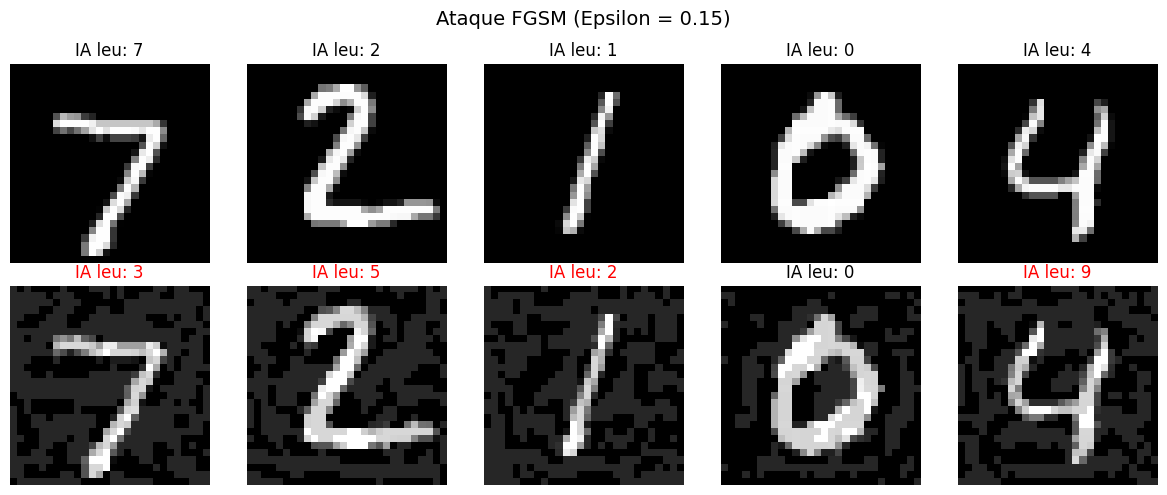

In [12]:
# Visualização
plt.figure(figsize=(12, 5))
for i in range(quantidade_imagens):
    # Linha de Cima: Limpas
    plt.subplot(2, quantidade_imagens, i + 1)
    plt.imshow(imagens_limpas[i].reshape(28, 28), cmap='gray')
    certeza_limpa = np.argmax(previsoes_limpas[i]) 
    plt.title(f"IA leu: {certeza_limpa}")
    plt.axis('off')

    # Linha de Baixo: Atacadas
    plt.subplot(2, quantidade_imagens, i + quantidade_imagens + 1)
    plt.imshow(imagens_adversarias[i].reshape(28, 28), cmap='gray')
    certeza_adv = np.argmax(previsoes_adversarias[i])
    plt.title(f"IA leu: {certeza_adv}", color='red' if certeza_adv != rotulos_reais[i] else 'black')
    plt.axis('off')

plt.suptitle(f"Ataque FGSM (Epsilon = {forca_do_ataque})", fontsize=14)
plt.tight_layout()
plt.show()